# Parte 1: Exploracion Inicial del Dataset
**Objetivo:** Realizar un analisis exploratorio inicial (EDA) para comprender la estructura del dataset, identificar problemas de calidad y caracterizar las variables antes de cualquier transformacion.

In [ ]:
import pandas as pd        # manipulación de datos
import numpy as np         # operaciones num
import matplotlib.pyplot as plt  # visualizaciones
import seaborn as sns      # visualizaciones estadisticas

Importo las librerias necesarias que son para trabajar con datos de python. Esto se hace ya que estas librerias son fundamentales para el flujo adecuado para la exploración, limpieza y visualización de datos.

## Carga del dataset

In [38]:
df= pd.read_csv('Food_Preference.csv')
print("Dataset cargado")

Dataset cargado


Se cargo el dataset entregado para disponer de una estructura tabular que permitiera aplicar operaciones de exploracion , limpieza, transformacion y posterior a la preparacion para el modelo.

## Vista general del dataset

In [ ]:
# primeras 5 filas
df.head()

,Timestamp,Participant_ID,Gender,Nationality,Age,Food,Juice,Dessert
0,2019/05/07 2:59:13 PM GMT+8,FPS001,NaN,Indian,24.0,Traditional food,Fresh Juice,Maybe
1,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
2,2019/05/07 2:59:45 PM GMT+8,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes
3,2019/05/07 3:00:05 PM GMT+8,FPS003,Male,Indian,31.0,Western food,Fresh Juice,Maybe
4,2019/05/07 3:00:11 PM GMT+8,FPS004,Female,Indian,25.0,Traditional food,Fresh Juice,Maybe


Se utiliza *head()* para poder validar visualmente la correcta carga del dataset. Con *head()* se cargan automaticamente 5 filas del dataset, de esta manera se logra comprender la estructura y contenido.

In [ ]:
#muestra la cantidad de filas y columnas
df.shape

(290, 8)

*df.shape()* ayuda a conocer el tamaño del conjunto de datos, esto es para dimensionar, observamos las filas y columnas que serian 290 y 8.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290 entries, 0 to 289
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Timestamp       290 non-null    object 
 1   Participant_ID  290 non-null    object 
 2   Gender          284 non-null    object 
 3   Nationality     290 non-null    object 
 4   Age             288 non-null    float64
 5   Food            290 non-null    object 
 6   Juice           290 non-null    object 
 7   Dessert         290 non-null    object 
dtypes: float64(1), object(7)
memory usage: 18.3+ KB


*df.info()* ayuda a entender la estructura del dataset antes de limpiarlo o transformarlo.
Tambien ayuda a detectar: valores nulos, columnas mal tipadas o incluso variables categoricas que vienen como texto

In [ ]:
# include='all' incluye tanto columnas numéricas como de texto. esta es la descripcion estadistica
df.describe(include='all')

,Timestamp,Participant_ID,Gender,Nationality,Age,Food,Juice,Dessert
count,290,290,284,290,288.000000,290,290,290
unique,285,288,5,28,NaN,7,2,3
top,2019/05/10 1:07:43 AM GMT+8,FPS002,Female,Indian,NaN,Traditional food,Fresh Juice,Maybe
freq,2,2,165,242,NaN,236,257,123
mean,NaN,NaN,NaN,NaN,31.625000,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,20.843326,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,-47.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,24.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,28.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,37.000000,NaN,NaN,NaN


Se utilizo la estadística descriptiva para obtener una vision global del comportamiento de las variables y detectar posibles anomalías o patrones relevantes antes de aplicar limpieza.

In [ ]:
numericas = df.select_dtypes(include=['number']).columns
categoricas = df.select_dtypes(include=['object']).columns

print("Variables numéricas:", list(numericas))
print("Variables categóricas:", list(categoricas))

Variables numéricas: ['Age']
Variables categóricas: ['Timestamp', 'Participant_ID', 'Gender', 'Nationality', 'Food', 'Juice', 'Dessert']


Separa las columnas en una lista según su tipo, para mayor orden y entendimiento de los datos. (numéricas y categóricas). De esta manera, cada tipo de variable se analiza y limpia de forma distinta

In [ ]:
df.groupby('Gender')['Age'].mean()

,Age
Gender,
FEMALE,29.000000
Femal,30.000000
Female,33.153374
MASCULINO,26.000000
Male,29.844828


Resume la informacion agrupándola por categorias. Esto ayuda a detectar patrones iniciales en los datos y entender mejor el comportamiento del dataset.
**Ejemplo :** Tenemos el group by de gender y age, en donde nos muestra la edad promedio de los generos. Aqui hay una anomalia ya que como se visualiza hay generos que se repiten porque o estan mal escritos, o estan en mayusculas, incluso alguno en español cuando el dataset esta en ingles.

In [ ]:
df.groupby('Nationality')['Age'].mean().sort_values(ascending=False)

,Age
Nationality,
Pakistani,115.666667
Indonesia,45.857143
Indian,31.400000
Japan,31.000000
MY,31.000000
Yemen,30.000000
Maldivian,28.500000
Masculino,27.000000
Korean,27.000000


Resume la informacion agrupándola por categorias. Esto ayuda a detectar patrones iniciales en los datos y entender mejor el comportamiento del dataset.
**Ejemplo :** En este group by se visualiza la nacionalidad con la edad promedio. El resultado tambien es parecido al de arriba ya que hay nacionalidades que se repiten netamente porque una nacionalidad esta en mayuscula y otra en minuscula (MALAYSIAN y Malaysia, es la misma pero la falta una "n"). Tambien hay una nacionalidad que esta vacia, pero si tiene edad...

##  Analisis de calidad de datos

In [ ]:
# VALORES NULOS ,identificar columnas con datos faltantes
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos[nulos > 0]) #se le pone mayor a 0 para que no muestre los valor que no tienen valores nulos

Valores nulos por columna:
Gender    6
Age       2
dtype: int64


La identificacion de valores nulos es una etapa clave de calidad de datos, ya que su presencia puede distorsionar estadisticas, visualizaciones y algoritmos posteriores. Aca podemos visualizar que **gender** tiene 6 valores nulos y **age** tiene 2 valores nulos.

In [ ]:
# filas duplicadas
duplicados = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados}")

Filas duplicadas encontradas: 2


Se revisaron registros duplicados para garantizar la integridad del dataset y evitar que observaciones repetidas generen sesgos en el analisis. Se visualiza que se encuentran 2 filas duplicadas.

## Analisis de variables categoricas

In [ ]:
# INCONSISTENCIAS EN VARIABLES CATEGORICAS en este caso se revisa los valores unicos para detectar variantes del mismo valor
categoricas = ['Gender', 'Nationality', 'Food', 'Juice', 'Dessert']

for col in categoricas:
    print(f"\n{'='*50}")
    print(f"  {col.upper()} — {df[col].nunique()} valores unicos")
    print(f"{'='*50}")
    print(df[col].value_counts(dropna=False).to_string())


  GENDER — 5 valores unicos
Gender
Female       165
Male         116
NaN            6
FEMALE         1
MASCULINO      1
Femal          1

  NATIONALITY — 28 valores unicos
Nationality
Indian         242
Malaysian       10
Indonesia        7
Pakistani        3
Maldivian        2
MY               2
Japan            2
Pakistani        2
Maldivian        1
Pakistan         1
Tanzanian        1
Masculino        1
Indonesian       1
Malaysian        1
Malaysia         1
MALAYSIAN        1
Nigerian         1
Algerian         1
Korean           1
Canadian         1
Seychellois      1
Indonesain       1
Indonesian       1
Malaysia         1
China            1
Mauritian        1
                 1
Yemen            1

  FOOD — 7 valores unicos
Food
Traditional food    236
Western Food         49
Western food          1
                      1
Traditional Food      1
western Food          1
traditional food      1

  JUICE — 2 valores unicos
Juice
Fresh Juice          257
Carbonated drinks     33

Se analizaron las variables categoricas para identificar inconsistencias de escritura, diferencias de mayúsculas/minúsculas, espacios innecesarios o errores tipográficos que puedan fragmentar categorías equivalentes. **Ejemplo:** en Gender hay 2 variables que son las mismas pero con diferncia de mayuscula y minuscula (FEMALE, female) o tambien en Nacionality que pasa lo mismo con (Malaysian y MALAYSIAN) o que esta mal escrito (Indonesain y Indonesian) , lo mismo pasa con la variable Food (western Food y Western Food).

## Analisis de la variable numérica: Age

In [ ]:
# estadistica de age
print(df['Age'].describe())
print()

# identificar outliers: edades fuera del rango humano razonable (5-100)
outliers_age = df[df['Age'].notna() & ((df['Age'] < 5) | (df['Age'] > 100))]
print(f"Registros con Age que estan fuera del rango (< 5 o > 100): {len(outliers_age)}")
print(outliers_age[['Participant_ID', 'Age']])

count    288.000000
mean      31.625000
std       20.843326
min      -47.000000
25%       24.000000
50%       28.000000
75%       37.000000
max      263.000000
Name: Age, dtype: float64

Registros con Age que estan fuera del rango (< 5 o > 100): 4
   Participant_ID    Age
21         FPS021    2.0
22         FPS022  200.0
42         FPS042  263.0
59         FPS059  -47.0


Se analizo en detalle la variable **Age** debido a su relevancia analítica y a la posibilidad de presentar valores atípicos o errores de digitación. Se visualiza la media, mediana, los percentiles 25% 50% 75%, el max y min, etc.

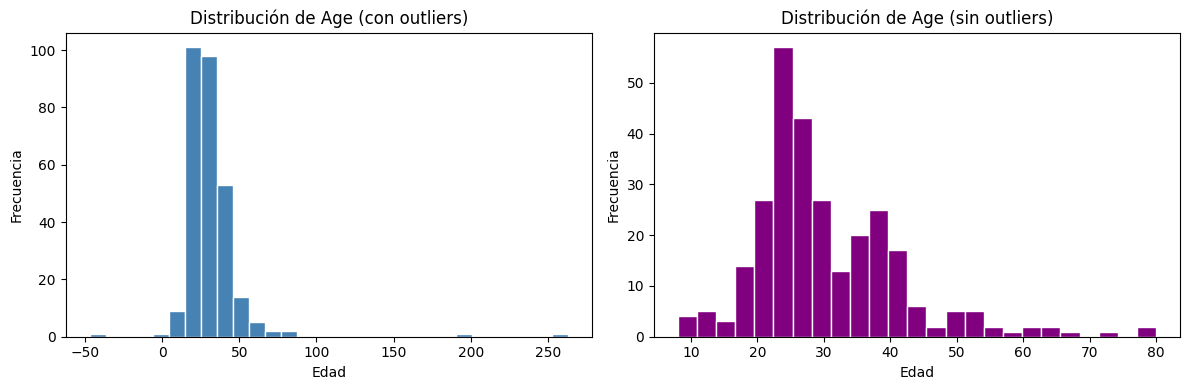

In [ ]:
# VISUALIZACION DE DISTRIBUCION DE AGE , se hace una comparacion de con outliers y sin outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma con todos los datos (incluyendo outliers)
axes[0].hist(df['Age'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Age (con outliers)')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

# Histograma sin outliers para ver la distribución real
age_limpia = df['Age'][(df['Age'] >= 5) & (df['Age'] <= 100)]
axes[1].hist(age_limpia.dropna(), bins=25, color='purple', edgecolor='white')
axes[1].set_title('Distribución de Age (sin outliers)')
axes[1].set_xlabel('Edad')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Se comparo la distribución de la edad antes y después de excluir outliers para evaluar visualmente el impacto de los valores extremos sobre la interpretación de la variable

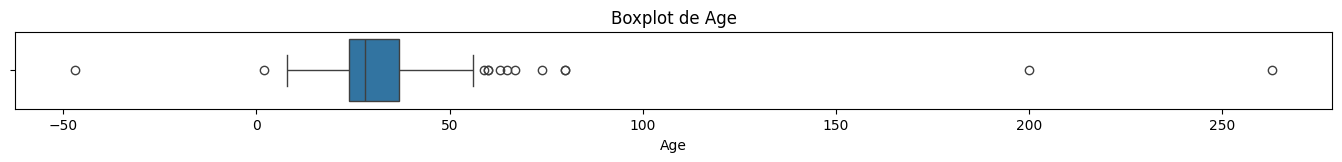

In [ ]:
#Creamos diagramas de caja o boxplot para las variables numericas para determinar outliers
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    plt.figure(figsize=(17, 1))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
    plt.show()

Se utilizaron diagramas de caja para identificar valores atípicos (outliers) en las variables numéricas, ya que permiten observar de forma compacta la distribución, la mediana y los posibles extremos.

# Parte 2: Manipulacion de datos

In [ ]:
df_relevante=df.copy()

Se utilizo la funcion `.copy()` para poder crear un respaldo independiente del dataset original

# Selección de columnas relevantes

In [ ]:
df_relevante = df_relevante.drop(columns=['Timestamp'])
print("Columnas después de la selección:")
print(df_relevante.columns.tolist())

Columnas después de la selección:
['Participant_ID', 'Gender', 'Nationality', 'Age', 'Food', 'Juice', 'Dessert']


Se decidio eliminar la columna timestamp ya que creemos que tener en consideracion la hora exacta donde se hizo la encuesta no afecta en nada

# Filtrado de filas

In [ ]:
# Se crea un nuevo dataset con las filas del dataset original filtradas de acuerdo a las condiciones definidas
#Se eligio que el rango de edad para pedir sea de los 12 años a los 100
edad_condicion=(df_relevante['Age']>=5) & (df_relevante['Age']<=100)
df_filtrado=df_relevante[edad_condicion].copy()
print(f"df con la selecion de columnas relevantes sin filtrar: {df_relevante.shape[0]} filas")
print(f"df con la seleccion de columnas relevantes filtrado: {df_filtrado.shape[0]}")

df con la selecion de columnas relevantes sin filtrar: 290 filas
df con la seleccion de columnas relevantes filtrado: 284


Se decidio hacer el filtrado de las filas por la edad desde los 5 años a los 100 solo por sentido comun, ya que no tendria sentido que un niño de 1 año tenga preferencias alimentarias. Ya que al momento de ver los datos nos dimos cuenta que habian edades que se consideran imposibles o edades negativas. Con este filtro de las edades nos aseguramos que el sistema lea edades reales y no errores de tipeo.

# Joins, merges y concatenaciones simples, si corresponde

In [ ]:
#Data frame auxiliar
datos_regiones = {
    'Nationality': [
        'Indian', 'Pakistani ', 'Pakistani', 'Pakistan', 'Maldivian ', 'Maldivian', # South Asia
        'Malaysian', 'Malaysian ', 'MY', 'MALAYSIAN', 'Malaysia', 'Malaysia ',      # Southeast Asia
        'Indonesia', 'Indonesian', 'Indonesian ', 'Indonesain',                     # Southeast Asia
        'Japan', 'China', 'Korean ',                                                # East Asia
        'Tanzanian', 'Nigerian ', 'Algerian ', 'Seychellois', 'Mauritian',          # Africa
        'Canadian',                                                                 # North America
        'Yemen'                                                                     # Middle East
    ],
    'Region': [
        'South Asia', 'South Asia', 'South Asia', 'South Asia', 'South Asia', 'South Asia',
        'Southeast Asia', 'Southeast Asia', 'Southeast Asia', 'Southeast Asia', 'Southeast Asia', 'Southeast Asia',
        'Southeast Asia', 'Southeast Asia', 'Southeast Asia', 'Southeast Asia',
        'East Asia', 'East Asia', 'East Asia',
        'Africa', 'Africa', 'Africa', 'Africa', 'Africa',
        'North America',
        'Middle East'
    ]
}
df_regiones=pd.DataFrame(datos_regiones)

#left join
df_manipulado = pd.merge(df_filtrado, df_regiones, on='Nationality', how='left')

print("Dataset despues de manipular: ", df_manipulado.shape)
df_manipulado.head(30)


Dataset despues de manipular:  (284, 8)


,Participant_ID,Gender,Nationality,Age,Food,Juice,Dessert,Region
0,FPS001,NaN,Indian,24.0,Traditional food,Fresh Juice,Maybe,South Asia
1,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes,South Asia
2,FPS002,Female,Indian,22.0,Western Food,Carbonated drinks,Yes,South Asia
3,FPS003,Male,Indian,31.0,Western food,Fresh Juice,Maybe,South Asia
4,FPS004,Female,Indian,25.0,Traditional food,Fresh Juice,Maybe,South Asia
5,FPS005,NaN,Indian,27.0,Traditional food,Fresh Juice,Maybe,South Asia
6,FPS006,Male,Indian,24.0,Traditional food,Fresh Juice,Yes,South Asia
7,FPS007,Female,Indian,34.0,Traditional food,Fresh Juice,Yes,South Asia
8,FPS008,Male,Pakistani,24.0,Western Food,Carbonated drinks,Yes,South Asia
9,FPS009,Female,Indian,19.0,Traditional food,Fresh Juice,Yes,South Asia


Creamos un `datos_regiones` ya que en la columna Nationality tenia muchos paises distintos, es decir faltas ortograficas, tipeo y formato. Por ejemplo escribieron "Indonesain" en vez de "Indonesian", o se escribio "MALAYSIAN" (todo en mayusculas), MY (como sigla) y Malaysia, o que la region tenga un espacio despues `Malaysia .`

Una vez que ya tenemos nuestra tabla auxiliar, necesitamos pegarla al dataset principal de preferencias alimentarias. Para esto utilizamos la funcion `pd.merge`

Cruzamos los datos usando la columna que ambas tablas tienen en comun on=Nationality. Usamos un left join para asegurar que la tabla izquierda (dataset original) mandara. Si hay algun dato que no lo pusimos en dato_regiones, el left join asegura que ese usuario no se borre, simplemente lo dejara como nulo, pero se conservara la preferencia de comida

# Parte 3: Limpieza de Dataset

In [ ]:
# Hacemos una copia para no modificar el dataset original
df_limpio = df.copy()

Se hace una copia para no modificar el dataset, como en este caso es una prueba. Para poder visualizar los valores antes y depues de modificar los datos, de esta manera se van comparando los valores. Pero se sabe que se pudo haber aplicado en el dataset original.

# Tratar valores faltantes (eliminar o imputar)texto en cursiva

In [ ]:
print("Valores nulos antes de limpiar:")
print(df_limpio.isnull().sum()[df_limpio.isnull().sum() > 0])

Valores nulos antes de limpiar:
Gender    6
Age       2
dtype: int64


Se verifico nuevamente la existencia de valores nulos para identificar con precision las variables afectadas y definir una estrategia de imputación adecuada según el tipo de dato.

In [ ]:
df_limpio['Age'] = df_limpio['Age'].fillna(df_limpio['Age'].median())

Reemplaza los valores nulos de la columna **Age** por la mediana de las edades. Esto se hizo con el fin de que Age es una variable **numerica**, y una forma correcta de tratar datos faltantes en variables numericas es usar una medida de tendencia central.
Se ocupa la mediana porque representa mejor el centro de la distribución cuando hay valores extremos y es medida robusta frente a valores atípicos

In [ ]:
for col in ['Gender', 'Nationality', 'Food', 'Juice', 'Dessert']:
    df_limpio[col] = df_limpio[col].fillna(df_limpio[col].mode()[0])

Este codigo recorre las columnas **categóricas** y reemplaza los valores faltantes con la moda. Los valores faltantes en variables categóricas se imputaron con la moda, ya que corresponde a la categoría más representativa y permite completar registros sin alterar significativamente la distribución genera.

In [ ]:
print("Valores nulos después de limpiar:")
print(df_limpio.isnull().sum()[df_limpio.isnull().sum() > 0])

Valores nulos después de limpiar:
Series([], dtype: int64)


Se realizó una **validación posterio**r al tratamiento de valores faltantes para comprobar la efectividad de la imputación y asegurar la integridad del dataset. Y ahora se puede identificar que ya no se encuentran valores nulos. La variable **Gender y Age** (que eran las variebles que anteriormente tenian nulos) **ya no contienen valores nulos.**

# Eliminar registros duplicados

In [ ]:
print(f"Duplicados antes: {df_limpio.duplicated().sum()}")

Duplicados antes: 2


Se cuantificaron los registros duplicados con el objetivo de evaluar si existia alguna redundancia en los datos antes de ir a aplicar su eliminación. Se visualiza que hay 2 duplicados.

In [ ]:
df_limpio = df_limpio.drop_duplicates()

Se eliminaron los registros que estaban duplicados, esto para evitar una redundancia y lograr reducir algun sesgos en el analisis y en las etapas posteriores del procesamiento de los datos.

In [ ]:
print(f"Duplicados después: {df_limpio.duplicated().sum()}")

Duplicados después: 0


Se volvio a ejecutar el resultado del proceso d**espues de su eliminación** de duplicados para asegurar que la limpieza se haya aplicado correctamente y asi fue, ya que ahora se visualiza que hay 0 valores duplicado, por lo tanto ya se eliminaron los valores dupliacos.

# Tratar los outliers identificados

In [ ]:
df_limpio.loc[(df_limpio['Age'] < 5) | (df_limpio['Age'] > 100), 'Age'] = np.nan
df_limpio['Age'] = df_limpio['Age'].fillna(df_limpio['Age'].median())

**1.-** Detecta edades fuera del rango razonable y las reemplaza por NaN.

**2.-** Luego reemplaza esos NaN por la mediana.

Esto se hizo ya que las variables edades fuera de rango hayan sido por problemas de digitación o algun dato anomalo, por lo tanto en vez de eliminar toda la fila completa, este enfoque permite conservar el registro, pero corrigiendo solamente el valor problematico.

In [ ]:
print("Resumen final del dataset limpio:")
df_limpio.info()

print("Valores nulos finales:")
print(df_limpio.isnull().sum())
print("-"*50)
print("Duplicados finales:")
print(df_limpio.duplicated().sum())

Resumen final del dataset limpio:
<class 'pandas.core.frame.DataFrame'>
Index: 288 entries, 0 to 289
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Timestamp       288 non-null    object 
 1   Participant_ID  288 non-null    object 
 2   Gender          288 non-null    object 
 3   Nationality     288 non-null    object 
 4   Age             288 non-null    float64
 5   Food            288 non-null    object 
 6   Juice           288 non-null    object 
 7   Dessert         288 non-null    object 
dtypes: float64(1), object(7)
memory usage: 20.2+ KB
Valores nulos finales:
Timestamp         0
Participant_ID    0
Gender            0
Nationality       0
Age               0
Food              0
Juice             0
Dessert           0
dtype: int64
--------------------------------------------------
Duplicados finales:
0


Resumen final de los valores nulos y duplicados.

# Unificar mayúsculas/minúsculas en columnas de texto

In [ ]:
cat_cols = ['Gender', 'Nationality', 'Food', 'Juice', 'Dessert']

for col in cat_cols:
    df_limpio[col] = df_limpio[col].astype(str).str.strip().str.lower()
    #astype: asegura que todo se trate como texto
    #strip: elimina espacios al inicio o al final
    #lower: convierte todo a minuscula

Se estandarizó el formato de las variables categóricas mediante conversión a minúsculas y eliminación de espacios innecesarios, con el fin de unificar categorías equivalentes y reducir inconsistencias

# Corregir errores tipográficos en variables categóricas

In [ ]:
# Diccionario con las correcciones específicas detectadas en la exploración
correcciones = {
    'Gender': {
        'Femal': 'Female',
        'Masculino': 'Male'
    },
    'Nationality': {
        'Indonesain': 'Indonesian',
        'Indonesia': 'Indonesian',
        'My': 'Malaysian',
        'Malaysia': 'Malaysian',
        'Pakistan': 'Pakistani',
        'Masculino': np.nan,
        'Female' : np.nan
    }
}

# Aplicamos los reemplazos al dataframe
df_limpio = df_limpio.replace(correcciones)

# Verificamos que las categorías hayan quedado limpias
print("Valores de Gender tras corrección:", df_limpio['Gender'].unique())
print("Valores de Nationality tras corrección:", df_limpio['Nationality'].unique())

Despues de arreglar las mayusculas, nos dimos cuenta que todavia habian errorres de tipeo. Y para eso creamos un diccionario llamado `correciones`, en la columna Gender arreglamos lo que era Femal, y decidimos unificar el idioma del dataset, pasando Masculino al ingles.

En la columna de Nationality, se agrupo todo lo que estaba mal escrito a lo que realmente estaba correcto.

Encontramos ademas que en nationality habian datos de Gender como Masculino, por lo que le pusimos un `np.nan `para que los arrojara como nulos.

Aplicamos todos los cambios de nuestro diccionario en un solo paso usando .replace(). Esto es mucho más rápido y limpio que ir corrigiendo error por error, ya que Pandas lee el diccionario y arregla todo automáticamente

Usamos .unique() para revisar qué valores quedaron en las columnas y confirmar visualmente que ya no existen errores de tipeo.

# Parte 4: Transformacion

# Crear agregaciones a partir de las variables originales (crear nuevas variables), si corresponde

In [ ]:
# Crear rango de edad (categorizar Age)
df_transformado = df_limpio.copy()

df_transformado['Age_Group'] = pd.cut(
    df_transformado['Age'],
    bins=[0, 18, 30, 50, 100],
    labels=['Niño/Adolescente', 'Joven', 'Adulto', 'Mayor']
)

# Ejemplo: contar preferencias de comida
top_food = df_transformado['Food'].value_counts()
print(top_food.head())

Food
Traditional food    236
Western Food         49
Western food          1
                      1
Traditional Food      1
Name: count, dtype: int64


Se generaron nuevas variables a partir de las originales con el objetivo de enriquecer el dataset y facilitar su interpretación y análisis.

In [41]:
for col in ['Gender', 'Nationality', 'Food', 'Juice', 'Dessert']:
    df_limpio[col] = df_limpio[col].astype(str).str.strip().str.lower()

In [45]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['Gender', 'Nationality', 'Food', 'Juice', 'Dessert']

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# USAR df_limpio
encoded = encoder.fit_transform(df_limpio[cat_cols])

df_encoded = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols))

# crear df_transformado  aquí
df_transformado = df_limpio.drop(columns=cat_cols).reset_index(drop=True)

df_encoded = df_encoded.reset_index(drop=True)

df_transformado = pd.concat([df_transformado, df_encoded], axis=1)


Transformamos las variables categóricas en formato numérico mediante One-Hot Encoding, ya que los modelos requieren datos numéricos.

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_transformado['Age'] = scaler.fit_transform(df_transformado[['Age']])

Se aplicó escalamiento a las variables numéricas para estandarizar sus valores y evitar sesgos en algoritmos sensibles a la magnitud de los datos.

# Definir y utilizar un(os) Pipeline(s) que contenga(n) los siguientes preprocesamiento: Codificación de variables categóricas y Escalamiento de variables numéricas

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

num_cols = ['Age']
cat_cols = ['Gender', 'Nationality', 'Food', 'Juice', 'Dessert']

pipeline = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

df_pipeline = pipeline.fit_transform(df_limpio)

Utilizamos un pipeline para automatizar el preprocesamiento, lo que permite aplicar las mismas transformaciones de forma eficiente y reproducible.

# Exportación

In [51]:
df_transformado.to_csv('food_preference_clean.csv', index=False)#guarda el dataset final en un archivo .csv

In [52]:
from google.colab import files
files.download('food_preference_clean.csv')#para descargar

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>